**Task 2: Quantitative analysis using pynance and TaLib**

Objective: Load historical stock price data, compute financial technical indicators, and
visualize the results to understand market behavior.


In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))

1. Prepare Your Data


In [2]:
# Import your custom modules
from src.data_loader import load_stock_data, process_financial_data

# Define file path
amzn_path = "../data/raw/amzn.csv"

# Load raw dataset
print("Loading raw data for amzn...")
raw_amzn = load_stock_data(amzn_path)

# Clean dataset
print("Applying financial cleaning rules...")
clean_amzn = process_financial_data(raw_amzn)


# Check data types
print(clean_amzn.dtypes)

# Missing values
print("Missing Values Remaining")
print(clean_amzn.isnull().sum())

# Preview dataset
print("Preview of the Clean amzn Dataset")
print(clean_amzn.head())

Loading raw data for amzn...
Applying financial cleaning rules...
Date      datetime64[us, UTC]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
dtype: object
Missing Values Remaining
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Preview of the Clean amzn Dataset
                       Date  Close    High     Low    Open     Volume
0 2009-01-02 00:00:00+00:00  2.718  2.7265  2.5535  2.5675  145928000
1 2009-01-05 00:00:00+00:00  2.703  2.7870  2.6515  2.7865  190196000
2 2009-01-06 00:00:00+00:00  2.868  2.9110  2.6875  2.7275  221602000
3 2009-01-07 00:00:00+00:00  2.810  2.8475  2.7675  2.8145  158854000
4 2009-01-08 00:00:00+00:00  2.858  2.8660  2.7290  2.7495  131558000


**2. Compute Technical Indicators with TA-Lib**

In [3]:
from src.indicators import add_moving_averages, add_rsi, add_macd, add_financial_metrics

print("Computing technical indicators for amzn...")

# Apply the mathematical transformations sequentially
clean_amzn = add_moving_averages(clean_amzn)
clean_amzn = add_rsi(clean_amzn)
clean_amzn = add_macd(clean_amzn)

# Apply the financial metrics (This creates the 'Daily_Return' column!)
clean_amzn = add_financial_metrics(clean_amzn)

print(" Indicators computed successfully! Previewing results:")
clean_amzn[
    [
        'Date', 
        'Close', 
        'SMA_20', 
        'RSI', 
        'MACD', 
        'Daily_Return'
    ]
].tail()

2026-05-10 10:54:23,326 - WARNING - PyNance calculation skipped: module 'pynance' has no attribute 'tech'


Computing technical indicators for amzn...
 Indicators computed successfully! Previewing results:


,Date,Close,SMA_20,RSI,MACD,Daily_Return
3769,2023-12-22 00:00:00+00:00,153.419998,148.578999,64.115558,3.135958,-0.002730
3770,2023-12-26 00:00:00+00:00,153.410004,148.863000,64.085644,3.118650,-0.000065
3771,2023-12-27 00:00:00+00:00,153.339996,149.178500,63.860893,3.063965,-0.000456
3772,2023-12-28 00:00:00+00:00,153.380005,149.531499,63.938728,2.989395,0.000261
3773,2023-12-29 00:00:00+00:00,151.940002,149.824000,59.012257,2.782032,-0.009388


**Apply PyNance for Financial Metrics**

In [4]:
from src.financial_metrics import add_financial_metrics

clean_amzn = add_financial_metrics(clean_amzn)

# Pass the analyzed_amzn dataframe you generated in the previous step
clean_amzn = add_financial_metrics(clean_amzn)
print("Metrics computed successfully!")
clean_amzn[['Date', 'Returns', 'Volatility_20', 'Cumulative_Return']].tail()

Metrics computed successfully!


,Date,Returns,Volatility_20,Cumulative_Return
3769,2023-12-22 00:00:00+00:00,-0.002730,0.011908,56.445917
3770,2023-12-26 00:00:00+00:00,-0.000065,0.011871,56.442240
3771,2023-12-27 00:00:00+00:00,-0.000456,0.011782,56.416483
3772,2023-12-28 00:00:00+00:00,0.000261,0.011678,56.431203
3773,2023-12-29 00:00:00+00:00,-0.009388,0.011946,55.901400


**Visualize the Data**


Generating Price & Moving Averages Chart...


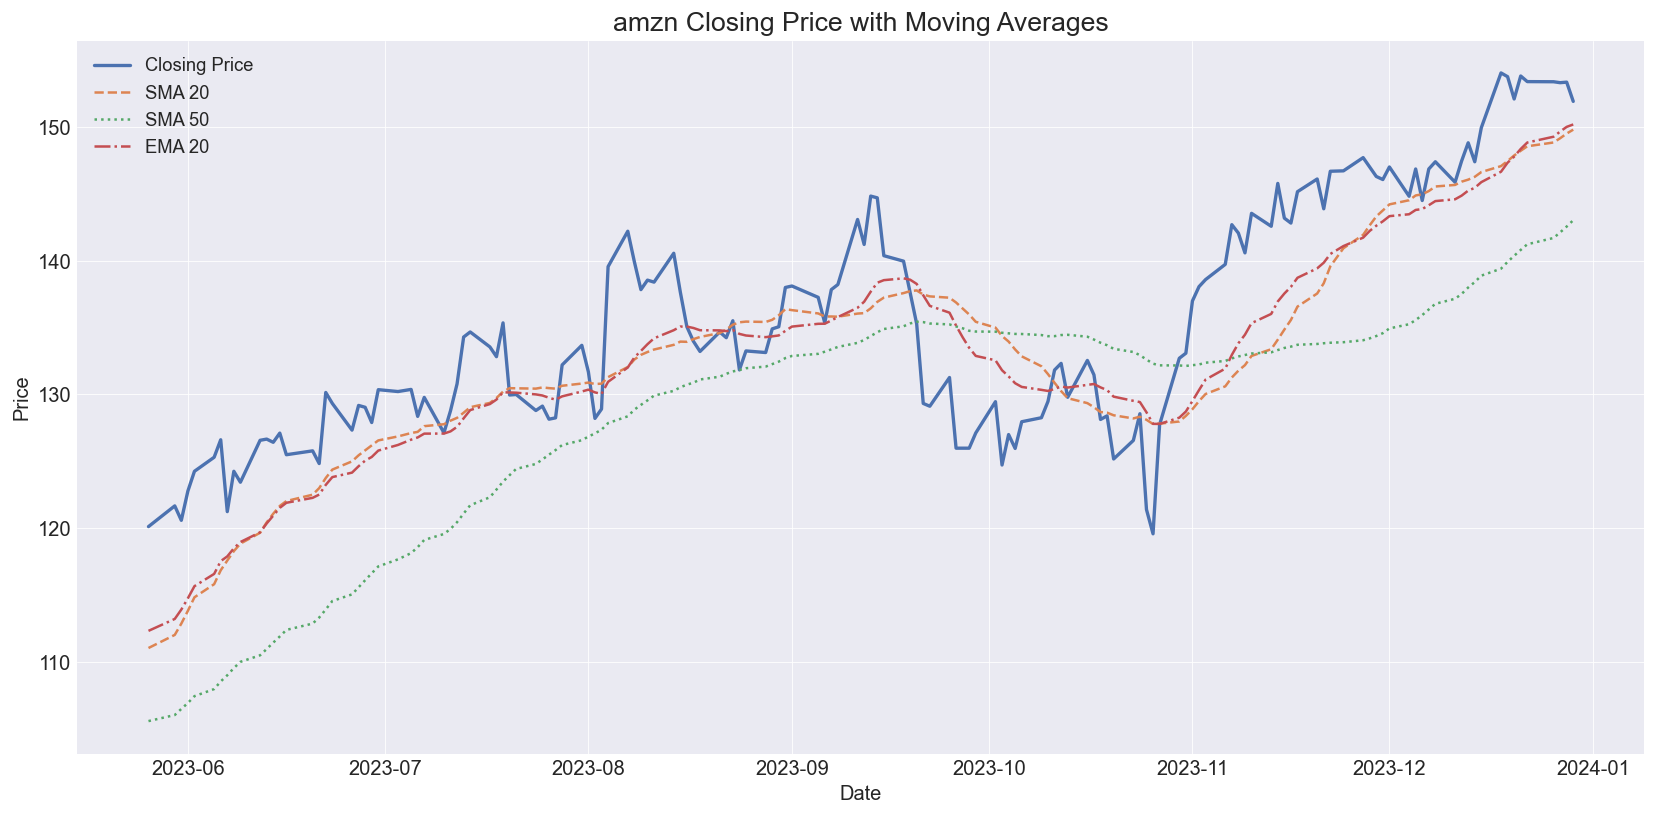

In [5]:
from src.visuals import set_visual_style, plot_price_and_ma, plot_rsi, plot_macd

# Apply the global darkgrid style
set_visual_style()

symbol = 'amzn'

# 1. Plot Price and Moving Averages
print("Generating Price & Moving Averages Chart...")
plot_price_and_ma(clean_amzn, symbol)

Generating RSI Chart...


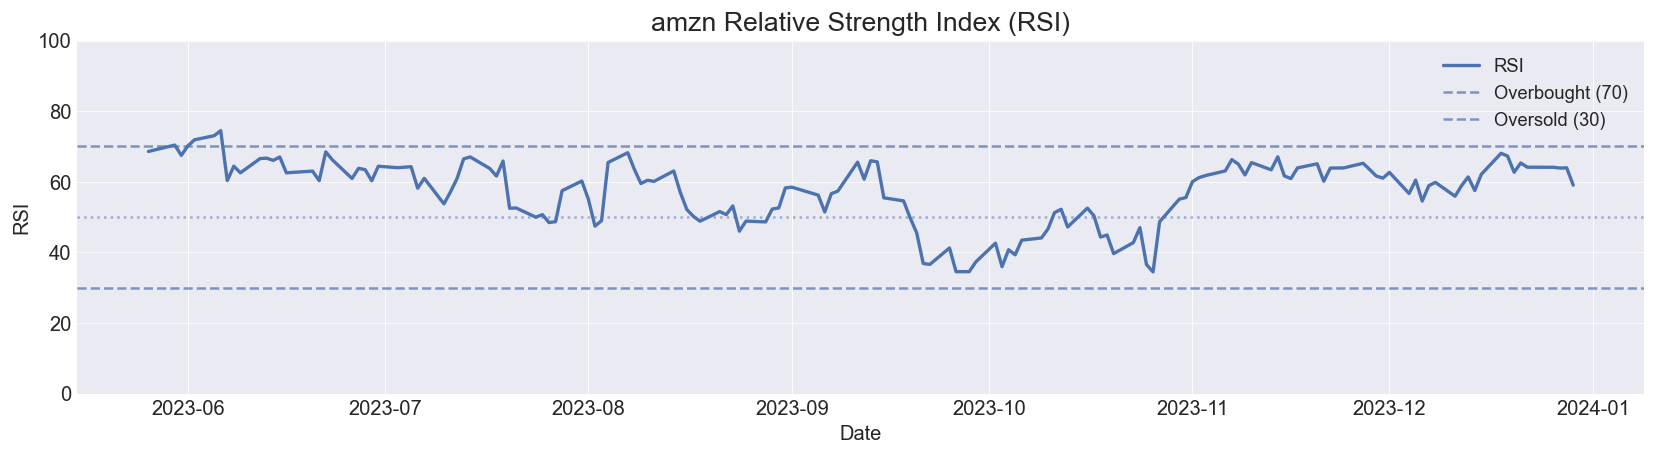

In [6]:
# 2. Plot Relative Strength Index
print("Generating RSI Chart...")
plot_rsi(clean_amzn, symbol)

Generating MACD Chart...


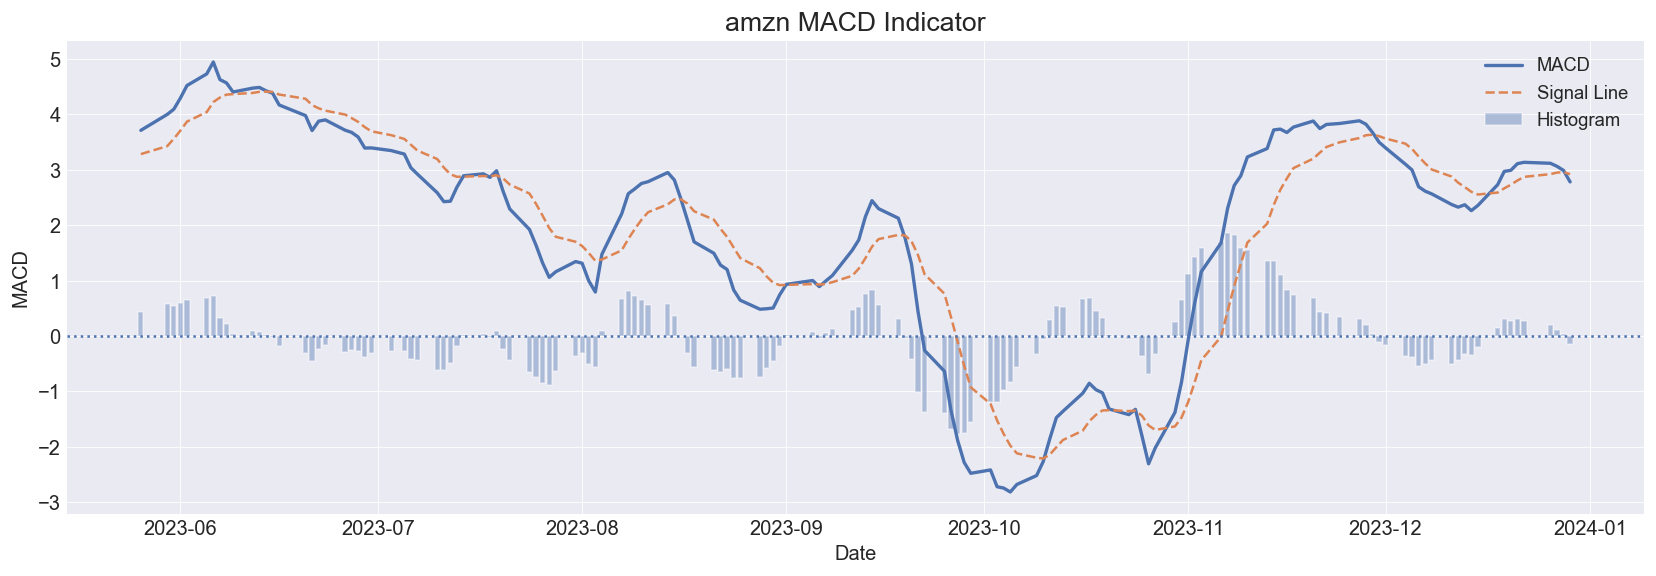

In [7]:
# 3. Plot MACD
print("Generating MACD Chart...")
plot_macd(clean_amzn, symbol)

In [8]:
# save the processed dataset for task 3
import os

# Ensure the directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save the finalized dataset
processed_amzn_path = f"../data/processed/{symbol}_processed.csv"
clean_amzn.to_csv(processed_amzn_path, index=False)

print(f" {symbol} quantitative analysis complete and saved to {processed_amzn_path}")

 amzn quantitative analysis complete and saved to ../data/processed/amzn_processed.csv
